# N Body Problem
Assessment 2 for Computational Physics and Modelling

Notebook by Elijah Gill

This notebook utilises custom functions from the python file "Nbody_Functions.py" to run.

This notebook is split into 3 main sections:
* Code Validation
* Code Convergence
* Comparison with Online Examples

In [1]:
from Nbody_Functions import *    # ensure the .py file is in the same folder as the notebook to import correctly

# Code Validation
See if code is working properly by checking if Kepler's laws are obeyed in multiple different simulations. Using 2 bodies.

* Kepler's 1st law: Orbits are ellipses. (Can be visually seen on the plots)

* Kepler's 2nd law: A planet sweeps out equal areas of its orbit in equal time intervals. (Conservation of angular momentum).

* Kepler's 3rd law: $P^2 = {4\pi a^3 \over{G(M_1 + M_2)}}$

where P = Orbital period, a = Semi-major axis, $M_1$, $M_2$ = Masses of object 1 and 2 respectively, G = Gravitational constant.

The first 2 laws can be checked using the orbital paths and angular momentum graphs respectively. The 3rd law is checked using the function: check_kepler().

5 individual systems are generated to check Kepler's laws.

Initial energy: -0.64
Initial Angular Momentum: [0.  0.  1.2]


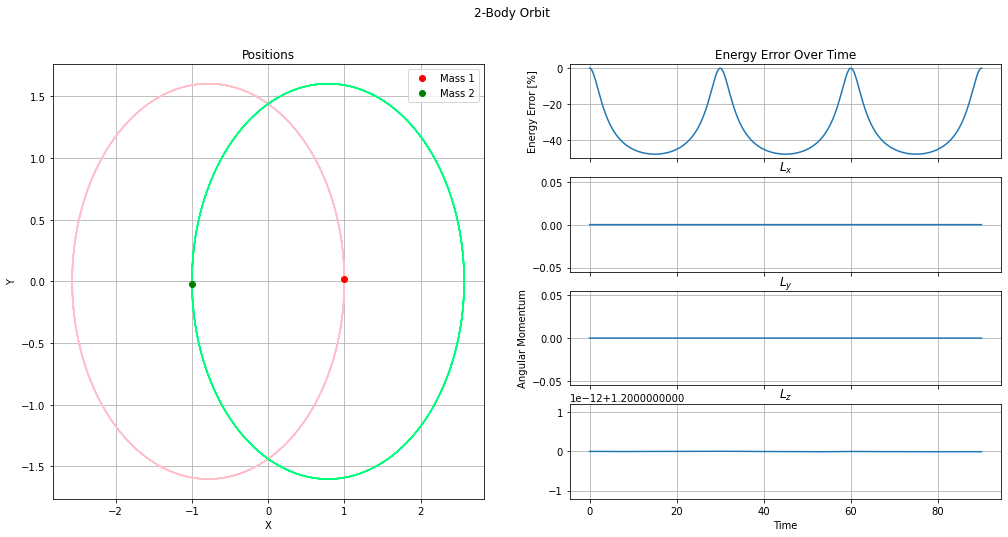

In [2]:
# System 1
# Make bodies
b1 = Body([1,0,0], [0,0.6,0], 1)
b2 = Body([-1,0,0], [0,-0.6,0], 1)
bodies = [b1,b2]

# Initialise parameters
delta = 0.01
t_end = 90

# Run verlet algorithm and plot the data
t_list, pos_list, vel_list, E_list, L_list = verlet_model(bodies, delta, t_end)
plot_orbits(t_list, pos_list, E_list, L_list)

# Check Kepler's 3rd law
p1, p2 = find_period(t_list, vel_list)
a1, a2 = find_semimajor_axis(pos_list, t_list, p1)
k11, k12 = check_kepler(p1, a1, a2, 1, b1.mass, b2.mass)

Initial energy: -1.25
Initial Angular Momentum: [0. 0. 2.]


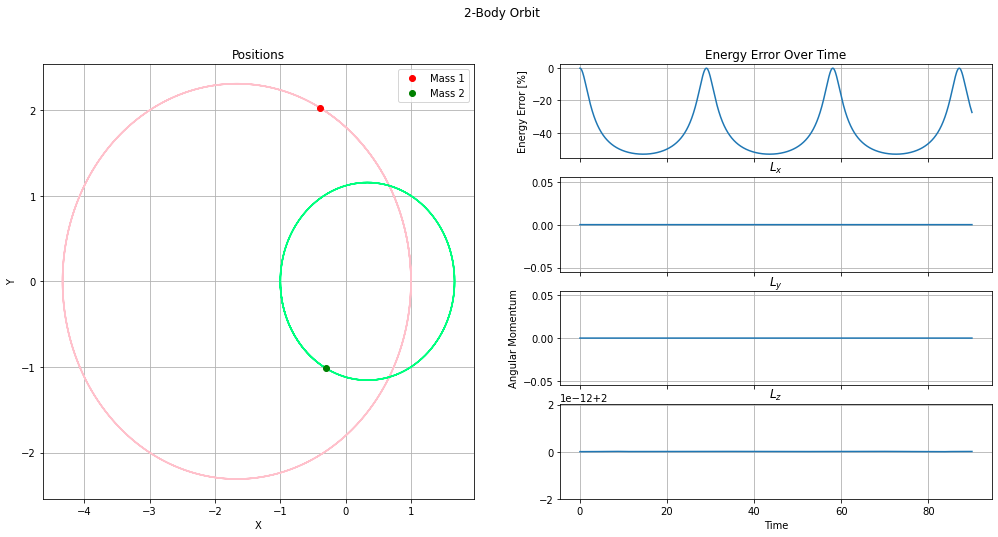

In [ ]:
# System 2
# Make bodies
b1 = Body([1,0,0], [0,1,0], 1)
b2 = Body([-1,0,0], [0,-0.5,0], 2)
bodies = [b1,b2]

# Initialise parameters
delta = 0.01
t_end = 90

# Run verlet algorithm and plot the data
t_list, pos_list, vel_list, E_list, L_list = verlet_model(bodies, delta, t_end)
plot_orbits(t_list, pos_list, E_list, L_list)

# Check Kepler's 3rd law
p1, p2 = find_period(t_list, vel_list)
a1, a2 = find_semimajor_axis(pos_list, t_list, p1)
k21, k22 = check_kepler(p1, a1, a2, 1, b1.mass, b2.mass)

Initial energy: -15000.0
Initial Angular Momentum: [  0.         0.       100.009999]


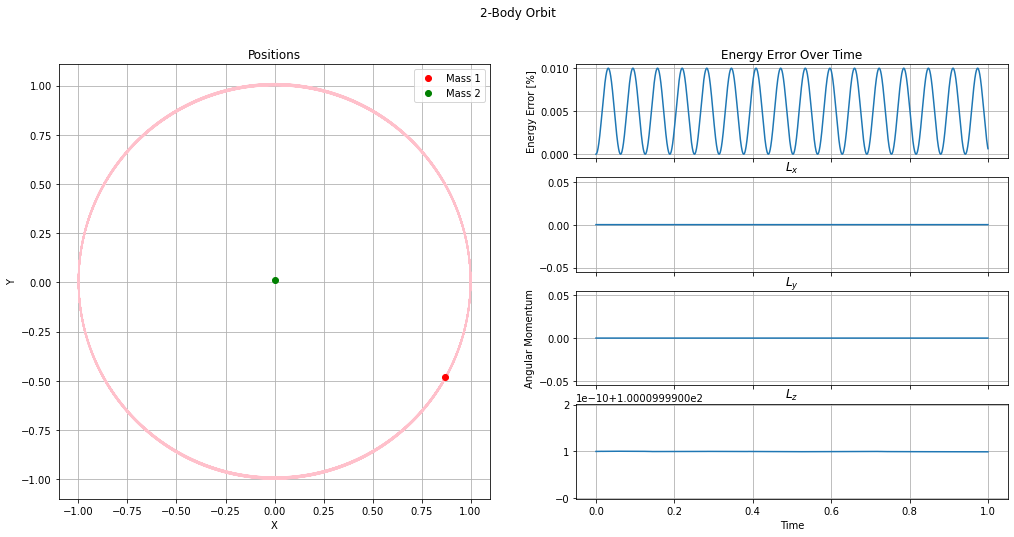

In [ ]:
# System 3
# Make bodies
b1 = Body([1,0,0], [0,100,0], 1)
b2 = Body([0,0,0], [0,0,0], 10000)
bodies = [b1,b2]

# Initialise parameters
delta = 0.0001
t_end = 1

# Run verlet algorithm and plot the data
t_list, pos_list, vel_list, E_list, L_list = verlet_model(bodies, delta, t_end)
plot_orbits(t_list, pos_list, E_list, L_list)

# Check Kepler's 3rd law
p1, p2 = find_period(t_list, vel_list)
a1, a2 = find_semimajor_axis(pos_list, t_list, p1)
k31, k32 = check_kepler(p1, a1, a2, 1, b1.mass, b2.mass)

Initial energy: -13499.6222
Initial Angular Momentum: [  0.           0.         182.00413159]


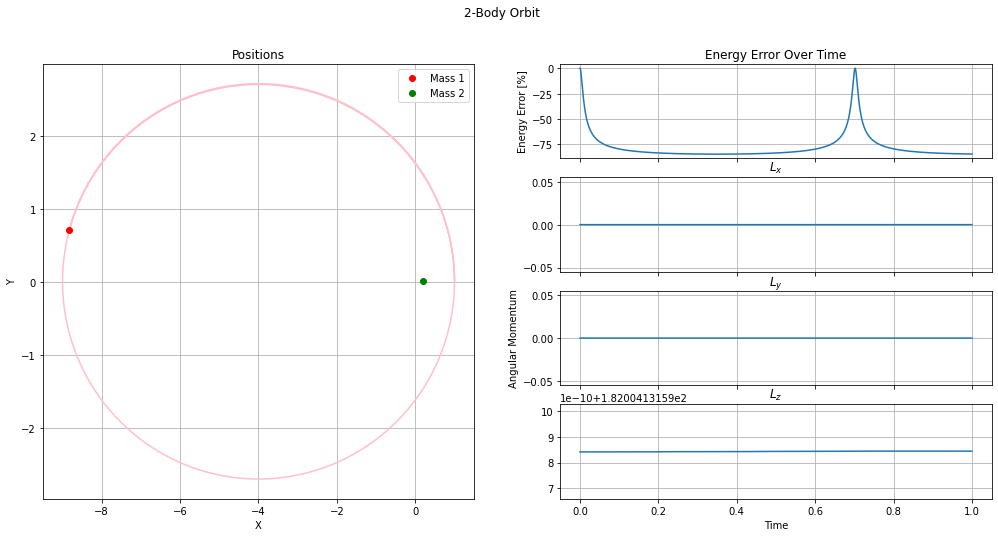

In [ ]:
# System 4
# Make bodies
b1 = Body([1,0,0], [0,151.66,0], 1)
b2 = Body([0.2,0,0], [0,0,0], 10000)
bodies = [b1,b2]

# Initialise parameters
delta = 0.0001
t_end = 1

# Run verlet algorithm and plot the data
t_list, pos_list, vel_list, E_list, L_list = verlet_model(bodies, delta, t_end)
plot_orbits(t_list, pos_list, E_list, L_list)

# Check Kepler's 3rd law
p1, p2 = find_period(t_list, vel_list)
a1, a2 = find_semimajor_axis(pos_list, t_list, p1)
k41, k42 = check_kepler(p1, a1, a2, 1, b1.mass, b2.mass)

Initial energy: -7.50004795
Initial Angular Momentum: [0.         0.         0.70851138]


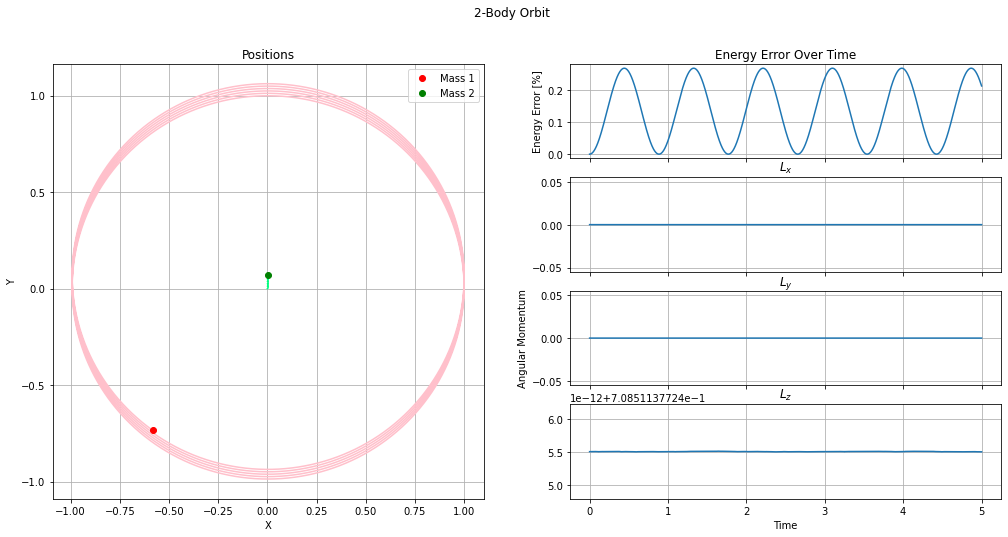

In [ ]:
# System 5
# Make bodies
b1 = Body([1,0,0], [0,7.071,0], 0.1)
b2 = Body([0,0,0], [0,0,0], 50)
bodies = [b1,b2]

# Initialise parameters
delta = 0.0001
t_end = 5

# Run verlet algorithm and plot the data
t_list, pos_list, vel_list, E_list, L_list = verlet_model(bodies, delta, t_end)
plot_orbits(t_list, pos_list, E_list, L_list)

# Check Kepler's 3rd law
p1, p2 = find_period(t_list, vel_list)
a1, a2 = find_semimajor_axis(pos_list, t_list, p1)
k51, k52 = check_kepler(p1, a1, a2, 1, b1.mass, b2.mass)

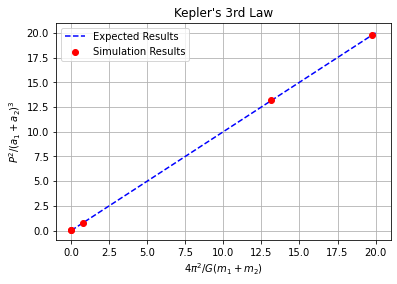

In [ ]:
# Plot the left and right hand sides of kepler's 3rd law equation
# Make lists of the data
lhs = [k11, k21, k31, k41, k51]
rhs = [k12, k22, k32, k42, k52]
# Expected plot is y=x
expected = [0,20]
# Plotting data
plt.plot(expected, expected, color='b', linestyle="--", zorder=2, label="Expected Results")
plt.scatter(rhs, lhs, color='r', zorder=3, label="Simulation Results")
# Tidying the plot
plt.grid(visible=True, zorder=1)
plt.xlabel("$4\pi^2 / G(m_1+m_2)$")
plt.ylabel("$P^2 / (a_1 + a_2)^3$")
plt.title("Kepler's 3rd Law")
plt.legend()

# Code Convergence
Tested using the 3 body orbits from: http://three-body.ipb.ac.rs/ and a solar system with planet positions, velocities and masses from: https://ssd.jpl.nasa.gov/horizons/app.html#/

Select a timestep value (delta) by uncommenting it, and run the cell to see if the code converges with that timestep or not.

Initial energy: -1.2871444950849997
Initial Angular Momentum: [0. 0. 0.]


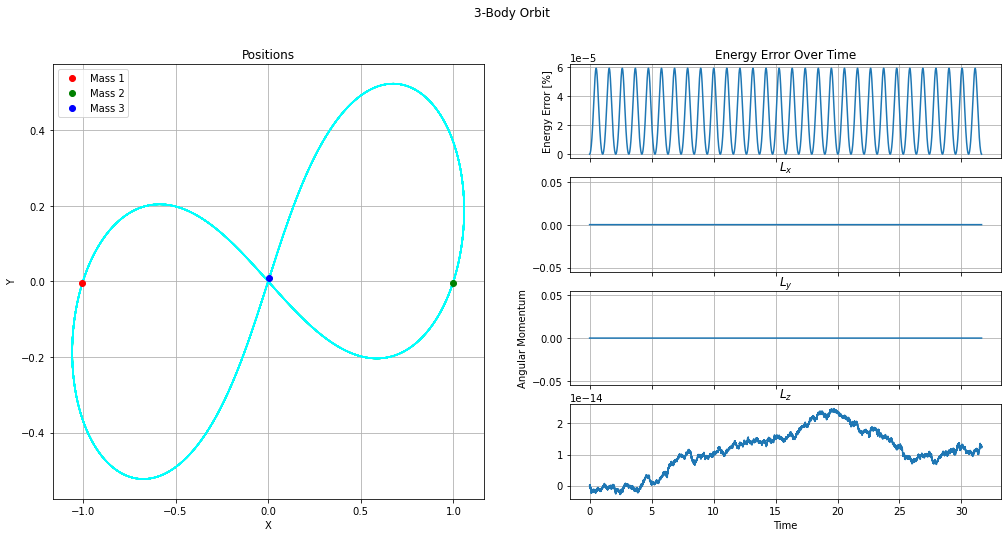

In [8]:
# Make bodies - Figure of 8
p1 = 0.347111  # Velocity Value
p2 = 0.532728  # Velocity Value

b1 = Body([-1,0,0], [p1,p2,0], 1)
b2 = Body([1,0,0], [p1,p2,0], 1)
b3 = Body([0,0,0], [-2*p1,-2*p2,0], 1)
bodies = [b1,b2,b3]

# Initialise Parameters - Uncomment one delta at a time to run the model with that timestep
#delta = 1
#delta = 0.1
#delta = 0.01
delta = 0.001
t_end = 5*6.324449  # 5 Periods

# Run Verlet Algorithm
t_list, pos_list, vel_list, E_list, L_list = verlet_model(bodies, delta, t_end, ep=1e-4)

# Plot the data
plot_orbits(t_list, pos_list, E_list, L_list)

Initial energy: -1.3058596462600003
Initial Angular Momentum: [0. 0. 0.]
Running for 1433513 iterations. This might take a while!
Iteration: 1000000/1433513


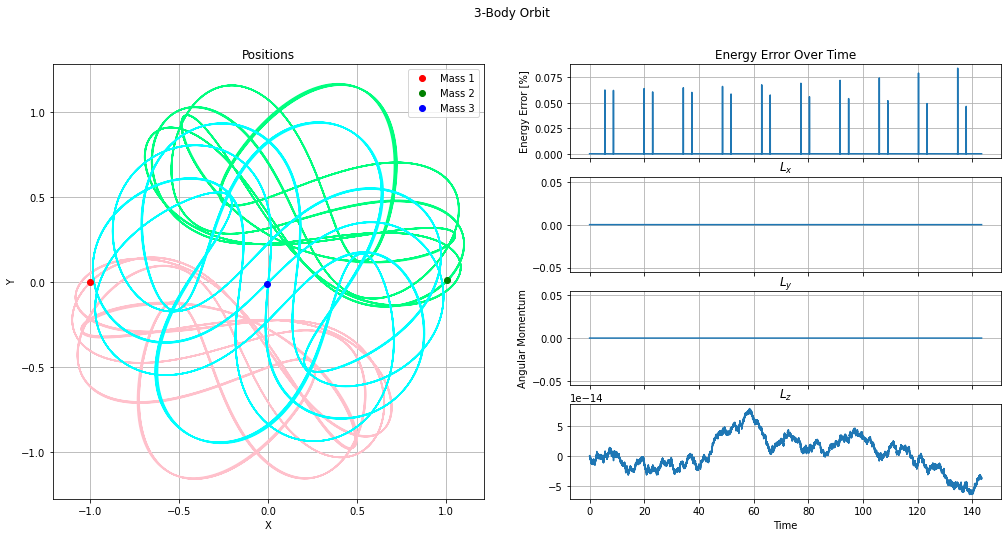

In [9]:
# Make bodies - Moth 2
p1 = 0.439166  # Velocity Value
p2 = 0.452968  # Velocity Value

b1 = Body([-1,0,0], [p1,p2,0], 1)
b2 = Body([1,0,0], [p1,p2,0], 1)
b3 = Body([0,0,0], [-2*p1,-2*p2,0], 1)
bodies = [b1,b2,b3]

# Initialise Parameters - Uncomment one delta at a time to run the model with that timestep
#delta = 0.1
#delta = 0.01
#delta = 0.001
delta = 0.0001
t_end = 5*28.670278  # 5 Periods

# Run Verlet Algorithm
t_list, pos_list, vel_list, E_list, L_list = verlet_model(bodies, delta, t_end, ep=1e-4)

# Plot the data
plot_orbits(t_list, pos_list, E_list, L_list)

Initial energy: 0.004435870445313917
Initial Angular Momentum: [0.00058281 0.00018467 0.02218992]


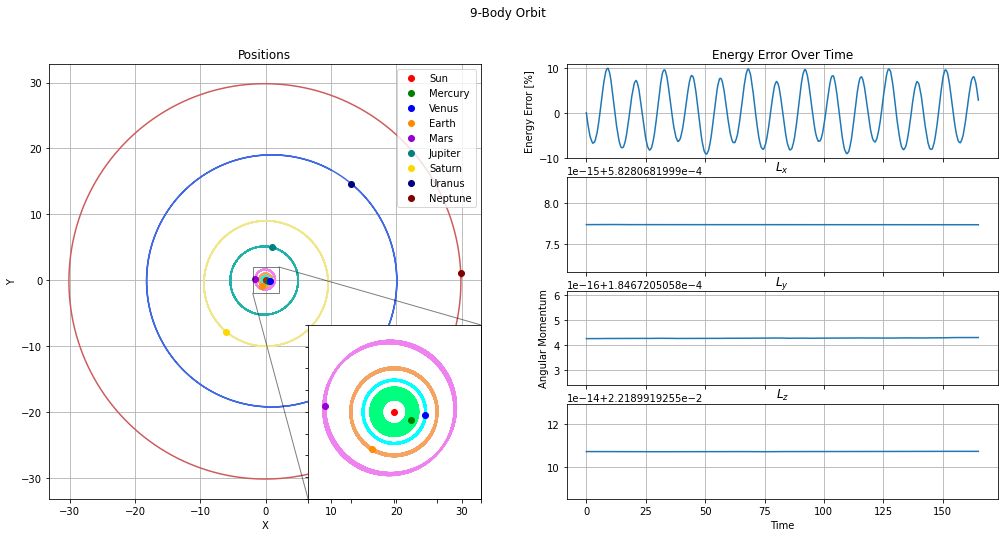

In [10]:
# Solar System
# Posititon, velocities and masses from https://ssd.jpl.nasa.gov/horizons/app.html#/
# Converted to AU and solar masses

# Bodies [km, km day-1, kg]
sun = Body([-4.967e5,-8.278e5,2.041e4], [1.259e-2,-2.769e-4,-2.369e-4], 1988410e24)
mercury = Body([-8.120e6,4.492e7,4.458e6],[-5.781e1,-6.235,4.794], 3.302e23)
venus = Body([-8.166e7,-7.229e7,3.722e6],[2.291e1,-2.645e1,-1.685], 48.685e23)
earth = Body([6.275e7,1.326e8,1.229e4],[-2.739e1,1.264e1,-1.843e-3], 5.972e24)
mars = Body([-2.507e7,-2.192e8,-3.953e6],[2.501e1,-6.260e-1,-6.262e-1], 6.417e23)
jupiter = Body([-2.157e8,7.466e8,1.732e6],[-1.271e1,-3.009,2.968e-1], 18.982e26)
saturn = Body([1.424e9,8.586e6,-5.684e7],[-5.931e-1,9.639,-1.439e-1], 5.683e26)
uranus = Body([1.495e9,2.503e9,-1.008e7],[-5.896,3.176,8.839e-2], 86.813e24)
neptune = Body([4.469e9,6.027e7,-1.042e8],[-1.096e-1,5.466,-1.104e-1], 102.409e24)

bodies = [sun, mercury, venus, earth, mars, jupiter, saturn, uranus, neptune]
# Convert to correct units [AU, AU yr-1, M_sol]
for body in bodies:
    body.pos /= 1.496e+8
    body.vel /= 4.744
    body.mass /= 1988410e24

# Initialise Parameters - Uncomment one delta at a time to run the model with that timestep
#delta = 1/365        # 1 Day
delta = 7/365        # 1 Week
#delta = 1/12         # 1 Month
#delta = 1            # 1 Year
#delta = 10           # 10 Years
t_end = 165           # Roughly 1 Neptune Orbital Period
label = ["Sun","Mercury","Venus","Earth","Mars","Jupiter","Saturn","Uranus","Neptune"]

# Run Verlet Algorithm
t_list, pos_list, vel_list, E_list, L_list = verlet_model(bodies, delta, t_end, G=G_sol)

plot_orbits(t_list, pos_list, E_list, L_list, label, zoom=True)

# Comparison with online examples
Link to 3 body test data: http://three-body.ipb.ac.rs/

This data has been put into the text file "Initial_Conditions.txt" for easier importing and reading.

The pre-existing examples are the quickest to run for, other systems run for much more iterations and so are slower to compute.

In [ ]:
# Import and show data - For user convenience when choosing a system name
# verlet_from_table() reads the text file itself when it is ran.
data = pd.read_csv("Initial_Conditions.txt", index_col=0)
data

,pos1x,pos1y,pos2x,pos2y,pos3x,pos3y,vel1x,vel1y,vel2x,vel2y,vel3x,vel3y,period,energy,L,delta,epsilon,orbits
Name,,,,,,,,,,,,,,,,,,
Figure 8,-1,0,1,0,0,0,0.347111,0.532728,0.347111,0.532728,-0.694222,-1.065456,6.324449,-1.287146,0,0.01000,0.010000,5
Butterfly 1,-1,0,1,0,0,0,0.306893,0.125507,0.306893,0.125507,-0.613786,-0.251014,6.235641,-2.170195,0,0.00005,0.000001,5
Butterfly 2,-1,0,1,0,0,0,0.392955,0.097579,0.392955,0.097579,-0.785910,-0.195158,7.003907,-2.008193,0,0.00001,0.000001,5
Butterfly 3,-1,0,1,0,0,0,0.405916,0.230163,0.405916,0.230163,-0.811832,-0.460326,13.865763,-1.846772,0,0.00001,0.000001,5
Butterfly 4,-1,0,1,0,0,0,0.350112,0.079339,0.350112,0.079339,-0.700224,-0.158678,79.475875,-2.113380,0,0.00001,0.000001,1
Bumblebee,-1,0,1,0,0,0,0.184279,0.587188,0.184279,0.587188,-0.368558,-1.174376,63.534541,-1.363754,0,0.00001,0.000001,1
Dragonfly,-1,0,1,0,0,0,0.080584,0.588836,0.080584,0.588836,-0.161168,-1.177672,21.270975,-1.440335,0,0.00005,0.000001,5
Goggles,-1,0,1,0,0,0,0.083300,0.127889,0.083300,0.127889,-0.166600,-0.255778,10.466818,-2.430116,0,0.00001,0.000001,3
Moth 1,-1,0,1,0,0,0,0.464445,0.396060,0.464445,0.396060,-0.928890,-0.792120,14.893911,-1.382281,0,0.00100,0.000001,5


Initial energy: -1.2871444950849997
Initial Angular Momentum: [0. 0. 0.]


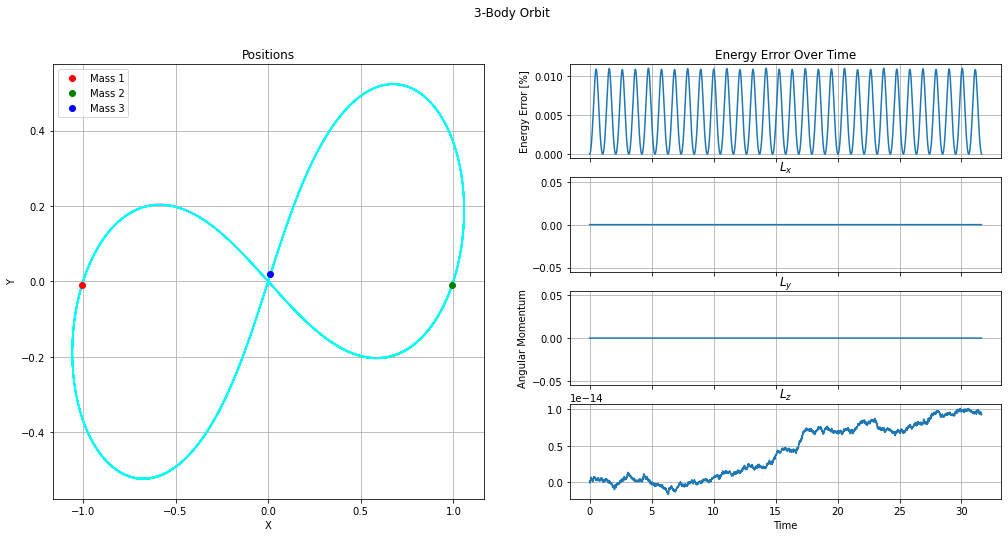

In [3]:
system = "Figure 8" # Change this string to one of the names in the table to plot it
verlet_from_table("Initial_Conditions.txt", system)

Initial energy: -2.1701940385059997
Initial Angular Momentum: [0. 0. 0.]
Running for 623564 iterations. This might take a while!


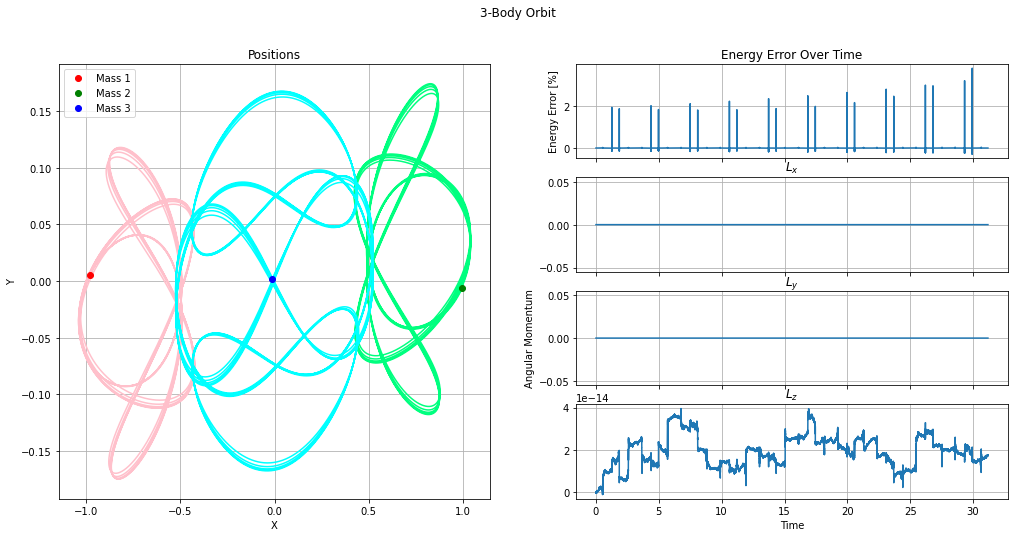

In [13]:
system = "Butterfly 1" # Change this string to one of the names in the table to plot it
verlet_from_table("Initial_Conditions.txt", system)

Initial energy: -1.440335152144
Initial Angular Momentum: [0. 0. 0.]
Running for 2127097 iterations. This might take a while!
Iteration: 1000000/2127097
Iteration: 2000000/2127097


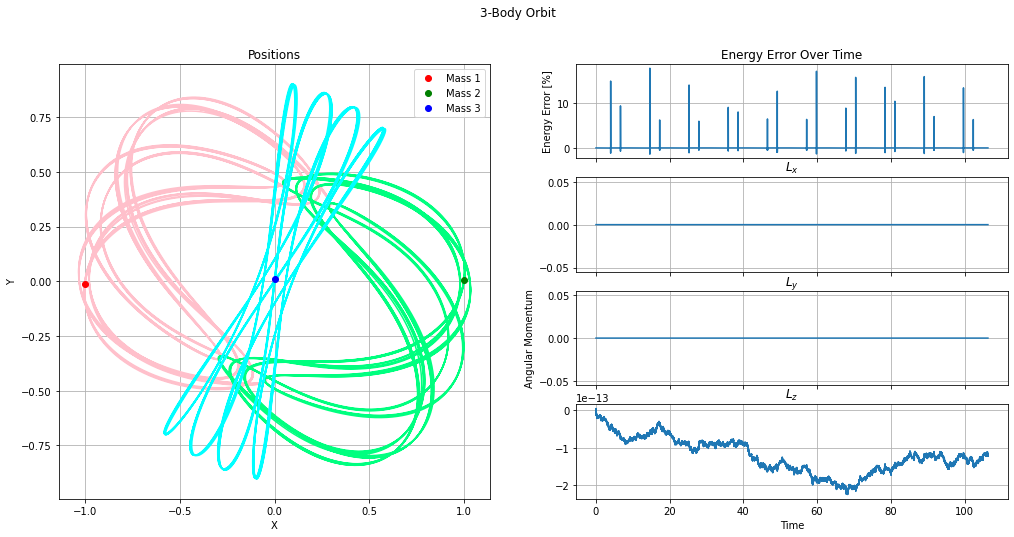

In [14]:
system = "Dragonfly" # Change this string to one of the names in the table to plot it
verlet_from_table("Initial_Conditions.txt", system)

Initial energy: -1.3822819551249999
Initial Angular Momentum: [0. 0. 0.]


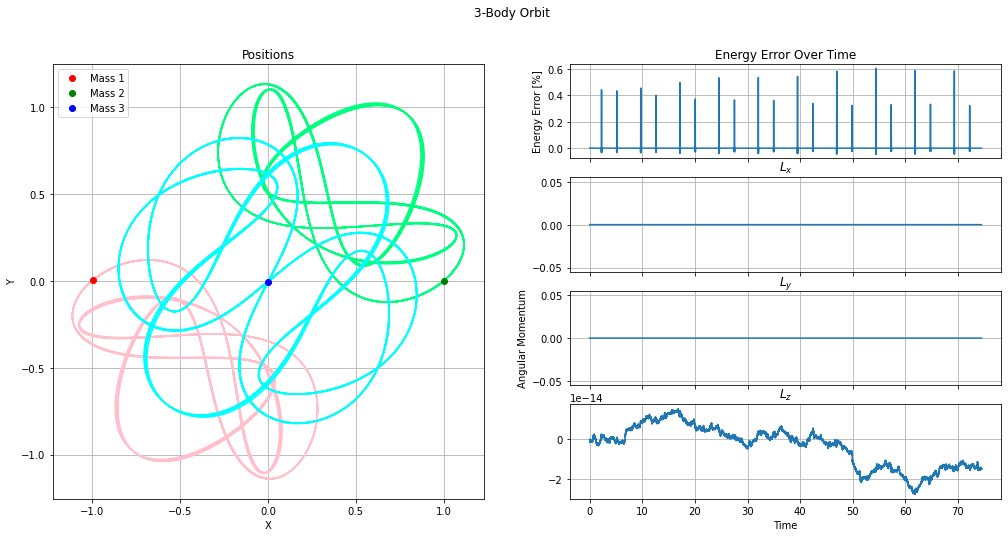

In [15]:
system = "Moth 1" # Change this string to one of the names in the table to plot it
verlet_from_table("Initial_Conditions.txt", system)

Initial energy: -1.4290111073799998
Initial Angular Momentum: [0. 0. 0.]
Running for 1732837 iterations. This might take a while!
Iteration: 1000000/1732837


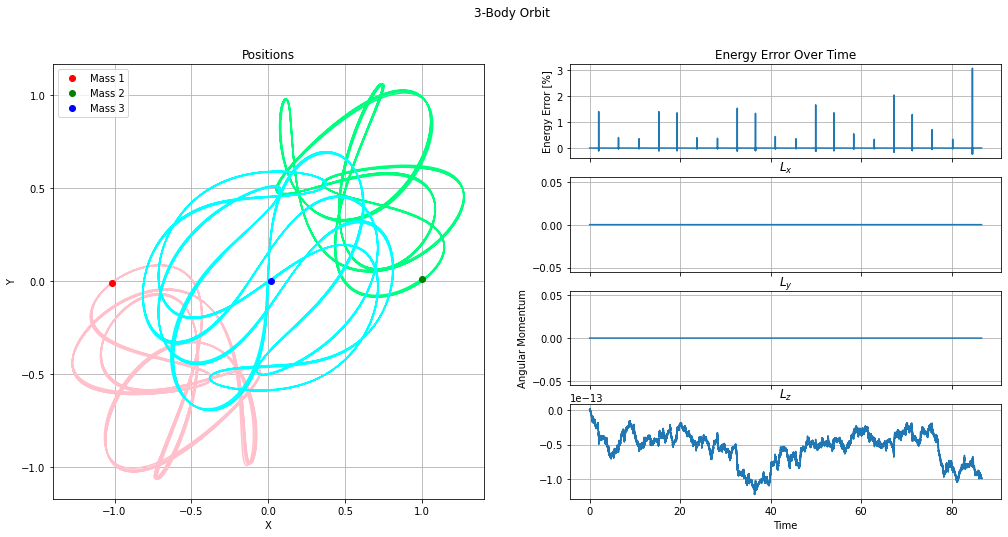

In [17]:
system = "Yin-Yang 1a" # Change this string to one of the names in the table to plot it
verlet_from_table("Initial_Conditions.txt", system)

## End of Notebook